<a href="https://colab.research.google.com/github/GeemaInduruwage/computer-vision-assignment-2/blob/main/Question01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import RANSACRegressor, LinearRegression
import matplotlib.pyplot as plt


In [ ]:
# Load the dataset
df = pd.read_csv('/content/lines.csv')

# Clean up column names by removing leading '#' character
df.columns = df.columns.str.replace('# ', '', regex=False)

# Display the first five rows
print("Table 1: First five rows of the dataset")
display(df.head())


Table 1: First five rows of the dataset


,# x1,x2,x3,y1,y2,y3
0,-5.305471,-4.060092,-5.261290,-12.666333,-3.796150,3.691712
1,-5.540359,-5.003180,-3.992592,-11.007727,-3.985625,4.900004
2,-4.982128,-4.584494,-4.331226,-11.697315,-3.589277,5.046863
3,-4.495706,-5.064138,-4.782018,-11.978010,-3.597071,4.635936
4,-4.442154,-4.411370,-4.567509,-12.414952,-2.799504,4.739699


### Part (a): Total Least Squares for the first line (x1, y1)


Total Least Squares parameters for the first line (x1, y1):
  Slope (m): 1.2207
  Intercept (c): -5.9872


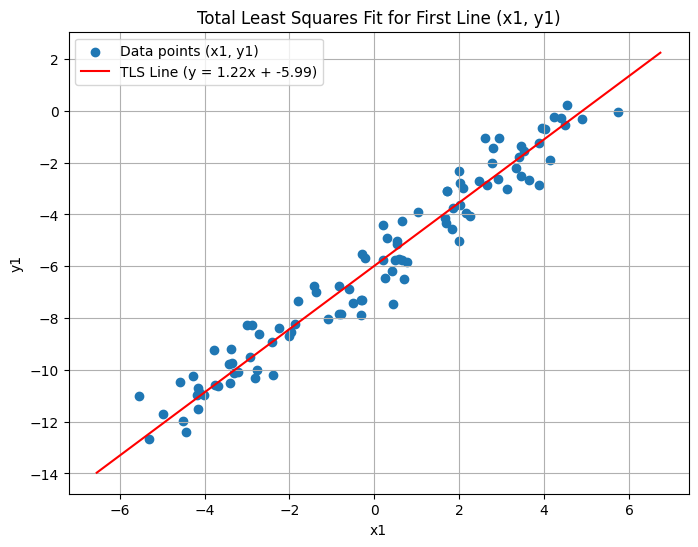

In [10]:
# Extract data for the first line
x1 = df['x1'].values
y1 = df['y1'].values

# Center the data
x1_mean = np.mean(x1)
y1_mean = np.mean(y1)
x1_centered = x1 - x1_mean
y1_centered = y1 - y1_mean

# Form the data matrix A
A = np.column_stack((x1_centered, y1_centered))

# Perform Singular Value Decomposition (SVD)
U, S, V = np.linalg.svd(A)

# The normal vector to the line is the last column of V
# The TLS solution corresponds to the singular vector associated with the smallest singular value
# which is the last column of V.T (or V[-1, :])
normal_vector = V[-1, :]
a, b = normal_vector[0], normal_vector[1]

# The line equation is ax + by + c = 0
# Since the line passes through the centroid (x1_mean, y1_mean),
c = -(a * x1_mean + b * y1_mean)

# Convert to y = mx + c form (if b is not zero)
if b != 0:
    slope_tls = -a / b
    intercept_tls = -c / b
    print(f"Total Least Squares parameters for the first line (x1, y1):")
    print(f"  Slope (m): {slope_tls:.4f}")
    print(f"  Intercept (c): {intercept_tls:.4f}")
else:
    print("The line is vertical (b=0), equation: x = -c/a")

# Plot the data and the fitted TLS line
plt.figure(figsize=(8, 6))
plt.scatter(x1, y1, label='Data points (x1, y1)')

# Generate points for the TLS line
if b != 0:
    x_line = np.linspace(min(x1) - 1, max(x1) + 1, 100)
    y_line = slope_tls * x_line + intercept_tls
    plt.plot(x_line, y_line, color='red', label=f'TLS Line (y = {slope_tls:.2f}x + {intercept_tls:.2f})')
else:
    plt.axvline(x=-c/a, color='red', linestyle='--', label=f'TLS Line (x = {-c/a:.2f})')

plt.title('Total Least Squares Fit for First Line (x1, y1)')
plt.xlabel('x1')
plt.ylabel('y1')
plt.legend()
plt.grid(True)
plt.show()


### Explanation of Part (a): Total Least Squares

Part (a) focuses on fitting a single line to the `(x1, y1)` data points using the Total Least Squares (TLS) method. Unlike ordinary least squares (OLS) which assumes errors only in the dependent variable (y), TLS accounts for errors in both x and y coordinates.

The process involves:
1.  **Centering the Data**: Subtracting the mean from both `x1` and `y1` to simplify calculations, as the TLS line will pass through the data's centroid.
2.  **Forming a Data Matrix**: Combining the centered `x` and `y` values into a matrix `A`.
3.  **Singular Value Decomposition (SVD)**: Performing SVD on matrix `A`. The last column of the `V` matrix (or `V.T[-1, :]`) gives the normal vector to the TLS line.
4.  **Deriving Line Parameters**: From the normal vector `(a, b)` and the centroid `(x1_mean, y1_mean)`, the constant `c` for the line equation `ax + by + c = 0` is calculated. This is then converted to the familiar `y = mx + c_intercept` form for plotting and reporting.

The plot visualizes the original data points and the fitted TLS line, showcasing how it captures the central tendency of the `(x1, y1)` dataset.

### Part (b): Fit three lines using RANSAC


Line 1 parameters (RANSAC):
  Slope (m): -0.5269
  Intercept (c): 1.9891
Line 2 parameters (RANSAC):
  Slope (m): 1.0578
  Intercept (c): 1.1126
Line 3 parameters (RANSAC):
  Slope (m): 1.1052
  Intercept (c): -6.4357


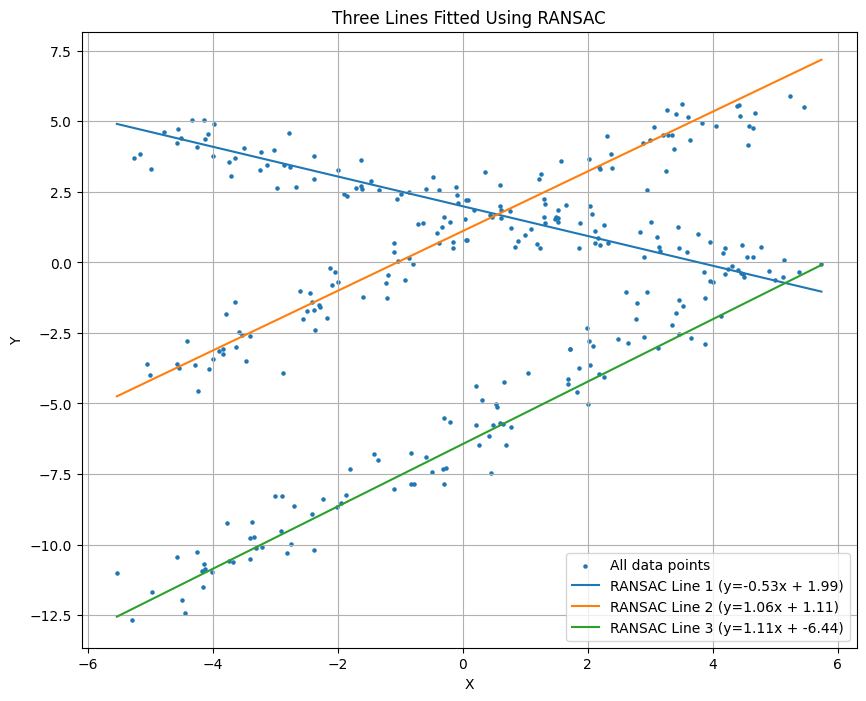

In [ ]:
# Prepare all points as indicated in the problem description
D = np.genfromtxt("/content/lines.csv", delimiter=",", skip_header=1)
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

# Reshape X_all for RANSACRegressor
X_all_reshaped = X_all.reshape(-1, 1)

# Store parameters of the fitted lines
lines_parameters = []
all_inliers = np.zeros(len(X_all), dtype=bool)

plt.figure(figsize=(10, 8))
plt.scatter(X_all, Y_all, s=5, label='All data points')

# Find three lines using RANSAC
for i in range(3):
    ransac = RANSACRegressor(LinearRegression(), min_samples=2, residual_threshold=0.5, random_state=42 + i)
    ransac.fit(X_all_reshaped[~all_inliers], Y_all[~all_inliers])

    # Get inliers for the current model
    current_inliers = ransac.inlier_mask_

    # Map current_inliers back to the original X_all_reshaped indices
    temp_inlier_indices = np.where(~all_inliers)[0][current_inliers]
    all_inliers[temp_inlier_indices] = True

    # Get the estimated parameters
    slope = ransac.estimator_.coef_[0]
    intercept = ransac.estimator_.intercept_
    lines_parameters.append({'slope': slope, 'intercept': intercept})

    print(f"Line {i+1} parameters (RANSAC):")
    print(f"  Slope (m): {slope:.4f}")
    print(f"  Intercept (c): {intercept:.4f}")

    # Plot the current fitted line
    x_line = np.linspace(min(X_all), max(X_all), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, label=f'RANSAC Line {i+1} (y={slope:.2f}x + {intercept:.2f})')

plt.title('Three Lines Fitted Using RANSAC')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()


### Explanation of Part (b): Fitting Three Lines using RANSAC

Part (b) addresses a more complex scenario where the data is expected to contain multiple linear relationships, potentially with significant noise or outliers. RANSAC (Random Sample Consensus) is an iterative algorithm used to estimate parameters of a mathematical model from a set of observed data containing outliers.

Here's how RANSAC is applied to find three distinct lines:
1.  **Data Preparation**: All `x` and `y` columns (`x1, x2, x3` and `y1, y2, y3`) from the CSV are flattened and combined into single `X_all` and `Y_all` arrays. This creates a large pool of points where the three lines are hidden.
2.  **Iterative Line Fitting**: A loop runs three times, one for each line to be identified.
    *   In each iteration, `RANSACRegressor` is initialized with a `LinearRegression` model. `min_samples=2` means at least two points are needed to fit a line, and `residual_threshold=0.5` defines how close a point must be to the model to be considered an inlier.
    *   RANSAC randomly selects a minimal subset of data points (2 in this case) to propose a model, then tests how many other data points fit this model within the `residual_threshold`. It repeats this process and keeps the model that has the most inliers.
    *   After fitting, the inliers for the current line are identified and marked in `all_inliers` so they are not considered for subsequent RANSAC runs (this helps find *different* lines).
3.  **Parameter Extraction and Plotting**: The slope and intercept of each found line are extracted and printed. Each line is then plotted on the same scatter plot of all data points, demonstrating how RANSAC successfully identifies and separates the underlying linear structures.